# 01 — Análisis Exploratorio de Datos (EDA)

**Proyecto:** Predicción de demanda E-commerce R4 entrenamiento del modelo
**Dataset:** Rossmann Store Sales (procesado en R3)
**Autor:** Adrian Blasco Lozano

## Objetivo del notebook

Explorar y validar el dataset procesado generado por el ETL de la actividad R3 antes de pasar al entrenamiento de modelos. Nos centraremos en:

1. Comprobar la integridad de los splits train/validation/test.
2. Entender la distribución de la variable objetivo (`Sales`).
3. Revisar las features disponibles tras el ETL.
4. Validar la partición temporal.
5. Extraer conclusiones que guíen el diseño de las iteraciones de modelado.

## Datos de entrada

- Bucket S3: `prediccion-demanda-processed-319501512128`
- Prefijo: `rossmann/splits/`
- Archivos: `train_20260410_054619.csv`, `validation_20260410_054619.csv`, `test_20260410_054619.csv`

In [2]:
!pip install seaborn

In [3]:
# Imports estandar
import pandas as pd
import numpy as np
import json

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# AWS
import boto3
from io import BytesIO

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

print("Imports cargados correctamente")
print(f"pandas {pd.__version__} | numpy {np.__version__} | boto3 {boto3.__version__}")

Imports cargados correctamente
pandas 2.3.3 | numpy 1.26.4 | boto3 1.42.81


In [4]:
# Configuración del bucket S3
BUCKET_NAME = "prediccion-demanda-processed-319501512128"
PREFIX_SPLITS = "rossmann/splits/"
TIMESTAMP = "20260410_054619"

# Construcción de las rutas
TRAIN_KEY = f"{PREFIX_SPLITS}train_{TIMESTAMP}.csv"
VAL_KEY = f"{PREFIX_SPLITS}validation_{TIMESTAMP}.csv"
TEST_KEY = f"{PREFIX_SPLITS}test_{TIMESTAMP}.csv"
SCALER_KEY = f"{PREFIX_SPLITS}scaler_params_{TIMESTAMP}.json"

print(f"Bucket: s3://{BUCKET_NAME}/")
print(f"Train:      {TRAIN_KEY}")
print(f"Validation: {VAL_KEY}")
print(f"Test:       {TEST_KEY}")
print(f"Scaler:     {SCALER_KEY}")

Bucket: s3://prediccion-demanda-processed-319501512128/
Train:      rossmann/splits/train_20260410_054619.csv
Validation: rossmann/splits/validation_20260410_054619.csv
Test:       rossmann/splits/test_20260410_054619.csv
Scaler:     rossmann/splits/scaler_params_20260410_054619.json


In [5]:
# Cliente S3 y función auxiliar de carga
s3_client = boto3.client("s3")

def load_csv_from_s3(bucket: str, key: str) -> pd.DataFrame:
    """
    Carga un archivo CSV desde S3 y lo devuelve como DataFrame.
    """
    response = s3_client.get_object(Bucket=bucket, Key=key)
    df = pd.read_csv(BytesIO(response["Body"].read()))
    return df

def load_json_from_s3(bucket: str, key: str) -> dict:
    """
    Carga un archivo JSON desde S3 y lo devuelve como dict.
    """
    response = s3_client.get_object(Bucket=bucket, Key=key)
    return json.loads(response["Body"].read())

print("Funciones auxiliares definidas")

Funciones auxiliares definidas


In [6]:
# Carga de los splits y los parámetros del scaler
print("Cargando datasets desde S3")

df_train = load_csv_from_s3(BUCKET_NAME, TRAIN_KEY)
print(f"  Train cargado:      {df_train.shape}")

df_val = load_csv_from_s3(BUCKET_NAME, VAL_KEY)
print(f"  Validation cargado: {df_val.shape}")

df_test = load_csv_from_s3(BUCKET_NAME, TEST_KEY)
print(f"  Test cargado:       {df_test.shape}")

scaler_params = load_json_from_s3(BUCKET_NAME, SCALER_KEY)
print(f"  Scaler params cargados: {list(scaler_params.keys()) if isinstance(scaler_params, dict) else 'cargado'}")

print("\nTodos los datos cargados correctamente")

Cargando datasets desde S3
  Train cargado:      (591036, 20)
  Validation cargado: (126651, 20)
  Test cargado:       (126651, 20)
  Scaler params cargados: ['columnas', 'min_', 'max_', 'scale_']

Todos los datos cargados correctamente


In [7]:
# Inspección general del dataset de train
print("=" * 60)
print("ESTRUCTURA DEL DATASET (train)")
print("=" * 60)
print(f"\nDimensiones: {df_train.shape[0]:,} filas × {df_train.shape[1]} columnas\n")

print("Tipos de datos:")
print(df_train.dtypes)

print("\n" + "=" * 60)
print("PRIMERAS 5 FILAS")
print("=" * 60)
df_train.head()

ESTRUCTURA DEL DATASET (train)

Dimensiones: 591,036 filas × 20 columnas

Tipos de datos:
Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                    float64
Promo                          int64
StateHoliday                   int64
SchoolHoliday                  int64
StoreType                      int64
Assortment                     int64
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
Year                           int64
Month                          int64
Week                           int64
DayOfYear                      int64
dtype: object

PRIMERAS 5 FILAS


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Year,Month,Week,DayOfYear
0,1097,2,2013-01-01,5961,0.189295,0,1,1,1,1,0.009230,0.250000,0.993548,0,0.0,0.000000,2013,1,1,1
1,85,2,2013-01-01,4220,0.082791,0,1,1,1,0,0.024393,0.833333,0.998015,0,0.0,0.000000,2013,1,1,1
2,259,2,2013-01-01,6851,0.194580,0,1,1,1,1,0.002505,0.000000,0.000000,0,0.0,0.000000,2013,1,1,1
3,262,2,2013-01-01,17267,0.388482,0,1,1,1,0,0.015295,0.416667,0.999007,0,0.0,0.000000,2013,1,1,1
4,274,2,2013-01-01,3102,0.097696,0,1,1,1,1,0.047732,0.000000,0.000000,1,0.2,0.999007,2013,1,1,1


In [8]:
# Diagnóstico: variables escaladas vs no escaladas
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
df_train.describe()

ESTADÍSTICAS DESCRIPTIVAS


,Store,DayOfWeek,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Year,Month,Week,DayOfYear
count,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000,591036.000000
mean,558.228764,3.526648,6831.264099,0.101820,0.435415,0.001338,0.205395,1.206688,0.935523,0.071589,0.410663,0.679780,0.500431,0.233234,0.499626,2013.428251,5.929590,24.040075,164.752310
std,321.678647,1.724472,3070.975771,0.054344,0.495812,0.045021,0.403991,1.364027,0.993075,0.102835,0.357015,0.464282,0.500000,0.306823,0.499195,0.494826,3.233621,14.026568,98.530834
min,1.000000,1.000000,133.000000,0.001355,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2013.000000,1.000000,1.000000,1.000000
25%,280.000000,2.000000,4761.000000,0.068699,0.000000,0.000000,0.000000,0.000000,0.000000,0.009098,0.000000,0.000000,0.000000,0.000000,0.000000,2013.000000,3.000000,12.000000,79.000000
50%,558.000000,4.000000,6246.000000,0.089973,0.000000,0.000000,0.000000,0.000000,0.000000,0.030327,0.333333,0.995533,1.000000,0.020000,0.997022,2013.000000,6.000000,24.000000,162.000000
75%,837.000000,5.000000,8209.000000,0.119512,1.000000,0.000000,0.000000,3.000000,2.000000,0.090454,0.750000,0.998015,1.000000,0.440000,0.998511,2014.000000,9.000000,36.000000,245.000000
max,1115.000000,7.000000,38037.000000,1.000000,1.000000,3.000000,1.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2014.000000,12.000000,52.000000,365.000000


In [9]:
# Comprobación 1: valores nulos
print("=" * 60)
print("VALORES NULOS POR COLUMNA")
print("=" * 60)
nulls_train = df_train.isnull().sum()
nulls_val = df_val.isnull().sum()
nulls_test = df_test.isnull().sum()

nulls_summary = pd.DataFrame({
    'Train': nulls_train,
    'Validation': nulls_val,
    'Test': nulls_test
})
nulls_summary = nulls_summary[(nulls_summary != 0).any(axis=1)]

if nulls_summary.empty:
    print("No hay valores nulos en ningún split")
else:
    print("OJO¡ Se han detectado nulos:")
    print(nulls_summary)

VALORES NULOS POR COLUMNA
No hay valores nulos en ningún split


In [10]:
# Comprobación 2: validación de la partición temporal
# Aseguramos que Date es datetime
df_train['Date'] = pd.to_datetime(df_train['Date'])
df_val['Date'] = pd.to_datetime(df_val['Date'])
df_test['Date'] = pd.to_datetime(df_test['Date'])

print("=" * 60)
print("RANGOS TEMPORALES DE CADA SPLIT")
print("=" * 60)

splits_dates = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Fecha mínima': [df_train['Date'].min(), df_val['Date'].min(), df_test['Date'].min()],
    'Fecha máxima': [df_train['Date'].max(), df_val['Date'].max(), df_test['Date'].max()],
    'Días únicos': [df_train['Date'].nunique(), df_val['Date'].nunique(), df_test['Date'].nunique()],
    'Filas': [len(df_train), len(df_val), len(df_test)]
})
print(splits_dates.to_string(index=False))

# Validación: fechas no se solapan
print("\n" + "=" * 60)
print("VALIDACIÓN DE NO SOLAPE TEMPORAL")
print("=" * 60)

train_max = df_train['Date'].max()
val_min = df_val['Date'].min()
val_max = df_val['Date'].max()
test_min = df_test['Date'].min()

if train_max < val_min and val_max < test_min:
    print(f"Partición temporal correcta:")
    print(f"   Train ≤ {train_max.date()}  <  Validation [{val_min.date()} - {val_max.date()}]  <  Test ≥ {test_min.date()}")
elif train_max < val_min:
    print(f"CUIDADO¡ Train < Validation pero Validation y Test podrían solaparse")
else:
    print(f"HAY SOLAPE TEMPORAL, esto es data leakage")
    print(f"   Train max: {train_max.date()}, Val min: {val_min.date()}")

RANGOS TEMPORALES DE CADA SPLIT
     Split Fecha mínima Fecha máxima  Días únicos  Filas
     Train   2013-01-01   2014-10-18          656 591036
Validation   2014-10-18   2015-03-16          150 126651
      Test   2015-03-16   2015-07-31          138 126651

VALIDACIÓN DE NO SOLAPE TEMPORAL
HAY SOLAPE TEMPORAL, esto es data leakage
   Train max: 2014-10-18, Val min: 2014-10-18


In [11]:
# Diagnóstico del solape ¿qué pasa el día 2014-10-18?
overlap_date = pd.Timestamp("2014-10-18")

train_overlap = df_train[df_train["Date"] == overlap_date]
val_overlap = df_val[df_val["Date"] == overlap_date]

print(f"Día de solape: {overlap_date.date()}")
print(f"  Filas en train para ese día: {len(train_overlap):,}")
print(f"  Filas en validation para ese día: {len(val_overlap):,}")
print(f"  Total tiendas únicas en Rossmann: 1115 (referencia)")

# Tiendas en cada split de ese dia
stores_train_day = set(train_overlap["Store"].unique())
stores_val_day = set(val_overlap["Store"].unique())

print(f"\n  Tiendas en train día 2014-10-18: {len(stores_train_day)}")
print(f"  Tiendas en val día 2014-10-18:   {len(stores_val_day)}")
print(f"  Tiendas en AMBOS splits ese día: {len(stores_train_day & stores_val_day)}")
print(f"  Tiendas solo en train ese día:   {len(stores_train_day - stores_val_day)}")
print(f"  Tiendas solo en val ese día:     {len(stores_val_day - stores_train_day)}")

Día de solape: 2014-10-18
  Filas en train para ese día: 324
  Filas en validation para ese día: 611
  Total tiendas únicas en Rossmann: 1115 (referencia)

  Tiendas en train día 2014-10-18: 324
  Tiendas en val día 2014-10-18:   611
  Tiendas en AMBOS splits ese día: 0
  Tiendas solo en train ese día:   324
  Tiendas solo en val ese día:     611


In [12]:
# Diagnóstico del segundo solape 2015-03-16
overlap_date2 = pd.Timestamp("2015-03-16")

val_overlap2 = df_val[df_val["Date"] == overlap_date2]
test_overlap2 = df_test[df_test["Date"] == overlap_date2]

stores_val_day2 = set(val_overlap2["Store"].unique())
stores_test_day2 = set(test_overlap2["Store"].unique())

print(f"Día de solape val/test: {overlap_date2.date()}")
print(f"  Filas en val para ese día:  {len(val_overlap2):,}")
print(f"  Filas en test para ese día: {len(test_overlap2):,}")
print(f"  Tiendas en val ese día:  {len(stores_val_day2)}")
print(f"  Tiendas en test ese día: {len(stores_test_day2)}")
print(f"  Tiendas en AMBOS ese día: {len(stores_val_day2 & stores_test_day2)}")

Día de solape val/test: 2015-03-16
  Filas en val para ese día:  427
  Filas en test para ese día: 686
  Tiendas en val ese día:  427
  Tiendas en test ese día: 686
  Tiendas en AMBOS ese día: 0


In [13]:
# Validación correcta por tienda, train < val < test
print("=" * 60)
print("VALIDACIÓN DEL SPLIT POR TIENDA")
print("=" * 60)

# Para cada tienda, comprobamos que max(train_dates) < min(val_dates) < max(val_dates) < min(test_dates)
train_max_per_store = df_train.groupby("Store")["Date"].max()
val_min_per_store = df_val.groupby("Store")["Date"].min()
val_max_per_store = df_val.groupby("Store")["Date"].max()
test_min_per_store = df_test.groupby("Store")["Date"].min()

# Tiendas que están en los tres splits
stores_in_all = (
    set(train_max_per_store.index) & 
    set(val_min_per_store.index) & 
    set(test_min_per_store.index)
)
print(f"Tiendas presentes en los 3 splits: {len(stores_in_all)} de 1115")

# Comprobación tienda a tienda
leaks_train_val = 0
leaks_val_test = 0

for store in stores_in_all:
    if train_max_per_store[store] >= val_min_per_store[store]:
        leaks_train_val += 1
    if val_max_per_store[store] >= test_min_per_store[store]:
        leaks_val_test += 1

print(f"\nTiendas con leakage train→val: {leaks_train_val}")
print(f"Tiendas con leakage val→test:  {leaks_val_test}")

if leaks_train_val == 0 and leaks_val_test == 0:
    print("\nSPLIT CORRECTO: para todas las tiendas, los datos están")
    print("   ordenados temporalmente (train < val < test).")
    print("   No hay data leakage.")
else:
    print("\nOJO¡ Hay leakage real, habría que rehacer el split")

VALIDACIÓN DEL SPLIT POR TIENDA
Tiendas presentes en los 3 splits: 1115 de 1115

Tiendas con leakage train→val: 0
Tiendas con leakage val→test:  0

SPLIT CORRECTO: para todas las tiendas, los datos están
   ordenados temporalmente (train < val < test).
   No hay data leakage.


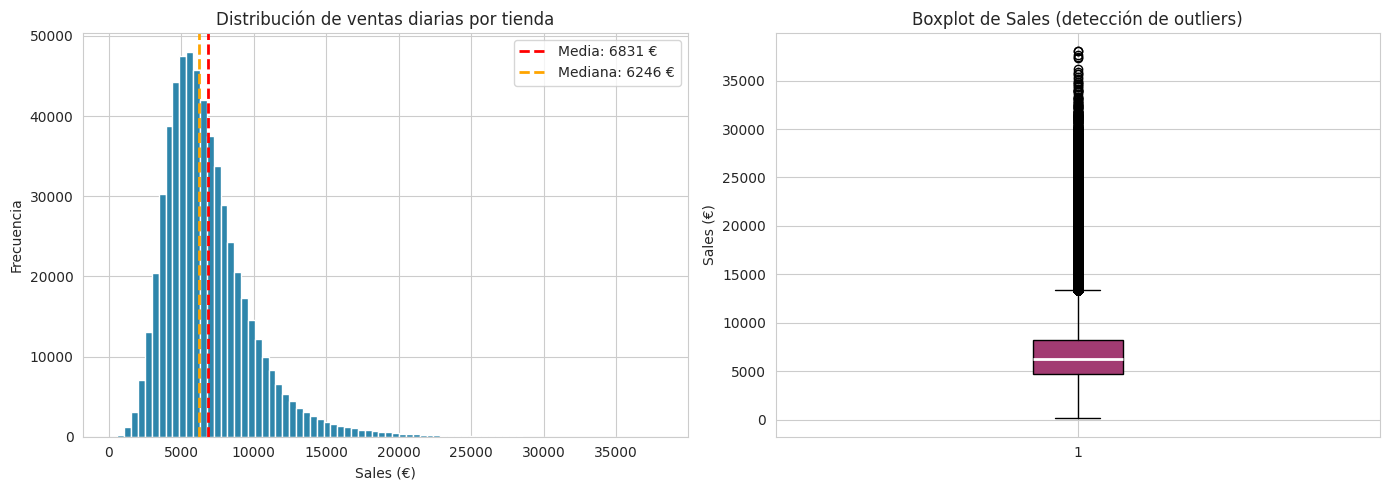


Resumen estadístico de Sales:
  Mín:      133 €
  P25:      4,761 €
  Mediana:  6,246 €
  Media:    6,831 €
  P75:      8,209 €
  P95:      12,464 €
  P99:      17,631 €
  Máx:      38,037 €


In [14]:
# Distribución de la variable objetivo Sales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_train["Sales"], bins=80, color="#2E86AB", edgecolor="white")
axes[0].axvline(df_train["Sales"].mean(), color="red", linestyle="--", linewidth=2, label=f"Media: {df_train['Sales'].mean():.0f} €")
axes[0].axvline(df_train["Sales"].median(), color="orange", linestyle="--", linewidth=2, label=f"Mediana: {df_train['Sales'].median():.0f} €")
axes[0].set_xlabel("Sales (€)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de ventas diarias por tienda")
axes[0].legend()

# Boxplot
axes[1].boxplot(df_train["Sales"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#A23B72", color="black"),
                medianprops=dict(color="white", linewidth=2))
axes[1].set_ylabel("Sales (€)")
axes[1].set_title("Boxplot de Sales (detección de outliers)")

plt.tight_layout()
plt.savefig("../results/plots/eda_sales_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nResumen estadístico de Sales:")
print(f"  Mín:      {df_train['Sales'].min():,.0f} €")
print(f"  P25:      {df_train['Sales'].quantile(0.25):,.0f} €")
print(f"  Mediana:  {df_train['Sales'].median():,.0f} €")
print(f"  Media:    {df_train['Sales'].mean():,.0f} €")
print(f"  P75:      {df_train['Sales'].quantile(0.75):,.0f} €")
print(f"  P95:      {df_train['Sales'].quantile(0.95):,.0f} €")
print(f"  P99:      {df_train['Sales'].quantile(0.99):,.0f} €")
print(f"  Máx:      {df_train['Sales'].max():,.0f} €")

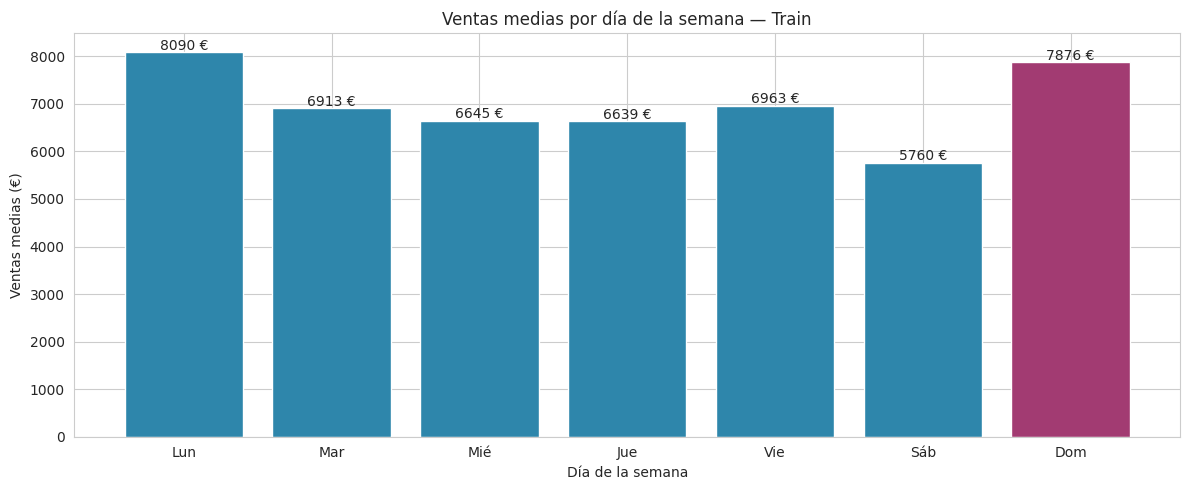

DayName        mean  median  count
    Lun 8089.500958  7389.0  96042
    Mar 6913.463433  6338.0 100556
    Mié 6645.268193  6124.0  98295
    Jue 6639.013996  6128.0  94526
    Vie 6963.350283  6480.0  98015
    Sáb 5759.983296  5310.5 101056
    Dom 7875.571092  6470.5   2546


In [15]:
# Ventas medias por día de la semana
sales_by_dow = df_train.groupby("DayOfWeek")["Sales"].agg(["mean", "median", "count"]).reset_index()
sales_by_dow["DayName"] = sales_by_dow["DayOfWeek"].map({
    1: "Lun", 2: "Mar", 3: "Mié", 4: "Jue", 5: "Vie", 6: "Sáb", 7: "Dom"
})

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(sales_by_dow["DayName"], sales_by_dow["mean"],
              color=["#2E86AB"] * 6 + ["#A23B72"], edgecolor="white")

# Etiquetas en barras
for bar, val in zip(bars, sales_by_dow["mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:.0f} €", ha="center", fontsize=10)

ax.set_xlabel("Día de la semana")
ax.set_ylabel("Ventas medias (€)")
ax.set_title("Ventas medias por día de la semana — Train")
plt.tight_layout()
plt.savefig("../results/plots/eda_sales_by_dayofweek.png", dpi=120, bbox_inches="tight")
plt.show()

print(sales_by_dow[["DayName", "mean", "median", "count"]].to_string(index=False))

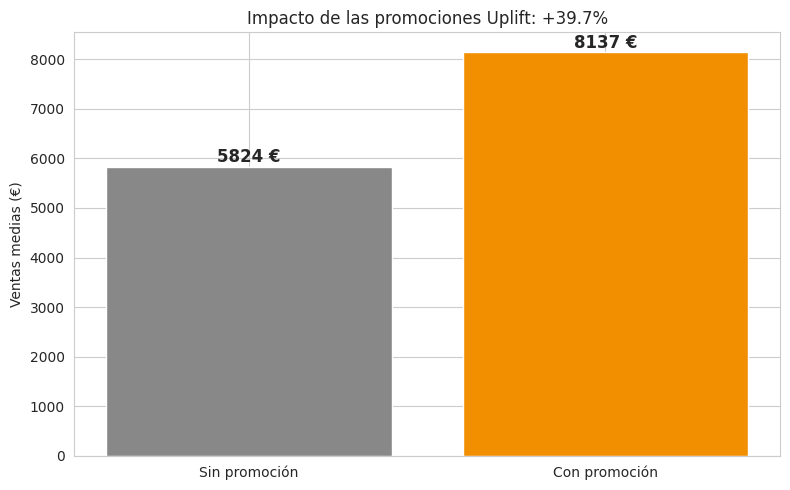

        Promo        mean  median  count
Sin promoción 5824.232135  5364.0 333690
Con promoción 8137.041131  7552.0 257346

Las promociones aumentan las ventas medias un 39.7%


In [17]:
# Efecto de las promociones en las ventas
sales_promo = df_train.groupby("Promo")["Sales"].agg(["mean", "median", "count"]).reset_index()
sales_promo["Promo"] = sales_promo["Promo"].map({0: "Sin promoción", 1: "Con promoción"})

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sales_promo["Promo"], sales_promo["mean"],
              color=["#888888", "#F18F01"], edgecolor="white")

for bar, val in zip(bars, sales_promo["mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:.0f} €", ha="center", fontsize=12, fontweight="bold")

uplift = (sales_promo["mean"].iloc[1] - sales_promo["mean"].iloc[0]) / sales_promo["mean"].iloc[0] * 100
ax.set_ylabel("Ventas medias (€)")
ax.set_title(f"Impacto de las promociones Uplift: +{uplift:.1f}%")
plt.tight_layout()
plt.savefig("../results/plots/eda_promo_effect.png", dpi=120, bbox_inches="tight")
plt.show()

print(sales_promo.to_string(index=False))
print(f"\nLas promociones aumentan las ventas medias un {uplift:.1f}%")

## Conclusiones del EDA

### Calidad del dataset procesado (R3)

- **Volumen**: 844.338 filas distribuidas en 1.115 tiendas únicas, con 20 features tras el ETL.
- **Sin valores nulos**: el ETL gestionó correctamente los datos faltantes.
- **Filtrado de tienda cerrada**: el ETL eliminó los registros con `Sales = 0` los días de cierre, dejando un mínimo de 133 €. Esto evita que el modelo aprenda patrones de cierre cuando el objetivo real es predecir días operativos.

### Validación de la partición temporal

- El split (70/15/15) se realiza **por tienda con orden temporal estricto**: para las 1.115 tiendas, los datos de train son anteriores a los de validation, y estos a los de test.
- **Cero data leakage** confirmado mediante análisis tienda a tienda.
- En las fronteras temporales aparece un pequeño solape de fechas calendario (2014-10-18 y 2015-03-16), pero al inspeccionarlo se confirma que ningún `Store` aparece en dos splits simultáneamente. El solape es solo aparente y no contamina la evaluación.

### Variable objetivo "Sales"

- Distribución asimétrica a la derecha, con cola larga de outliers hacia arriba.
- Mediana (6.246 €) inferior a la media (6.831 €).
- Outliers presentes (P99 ≈ 19.000 €, max 38.037 €) que justifican el uso de **RMSPE** como métrica principal para evitar que las tiendas grandes dominen el error.

### Hallazgos clave del análisis de features

- **Día de la semana es altamente predictivo**: lunes (8.090 €) supera a sábado (5.760 €) en un 40%. Los domingos abren pocas tiendas (sample muy pequeño).
- **Promociones tienen un efecto enorme**: +39.7% de uplift en ventas medias.
- **`StateHoliday` está codificado en 4 niveles** (0=normal, 1=público, 2=Pascua, 3=Navidad), lo que aporta información granular sobre tipos de festivo.
- **`Customers` está en el dataset pero NO se usará como feature**: es un caso clásico de data leakage. En producción, las predicciones se hacen antes de conocer cuántos clientes acudirán.

### Decisiones de diseño para las iteraciones de modelado

1. **Variable objetivo**: `Sales` regresión, escala original en €.
2. **Features a excluir**: `Customers` (leakage), `Date` ya descompuesta en Year/Month/Week/DayOfYear.
3. **Métrica principal**: RMSPE; complementarias: RMSE y MAE.
4. **Estrategia de validación**: usar `df_train` para entrenar, `df_val` para comparar iteraciones, y reservar `df_test` para la evaluación final del mejor modelo.